In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
import random
import h5py
import neurokit2 as nk

In [6]:
random.seed(43)
np.random.seed(42)

# file_name = os.path.splitext(os.path.basename(__file__))[0]
file_name = 'extractor_v2'

DATA_DIR = os.path.join(os.getcwd(), 'processed_data_60min_nsr_5min_af')
csv_file_name = '200x20_extracted_rr_intervals.csv'
csv_path = os.path.join(DATA_DIR, csv_file_name)
EXPORT_DIR = os.path.join(os.getcwd(), 'exported_plots', file_name)
os.makedirs(EXPORT_DIR, exist_ok=True)

df = pd.read_csv(csv_path)
patients = df['patient_id'].unique()

In [113]:

patient = np.random.choice(patients, size=1, replace=False)[0]
episodes = df[df['patient_id'] == patient]['episode_id'].unique()
episode = np.random.choice(episodes, size=1, replace=False)[0]
segments = df[(df['patient_id'] == patient) & (df['episode_id'] == episode) & (df['TimeToEvent'] > 0)].sort_values(by='TimeToEvent')

time_to_event = segments['TimeToEvent'].values/60 # Convert to minutes
rmssd_values = segments['RMSSD'].values
pnn50_values = segments['pNN50'].values
sdnn_values = segments['SDNN'].values
alpha_1_values = segments['alpha_1'].values
sample_entropy_values = segments['sample_entropy'].values
approximate_entropy_values = segments['approximate_entropy'].values
segments['file_name'] = segments.apply(lambda row: f"{row['patient_id']}_{row['episode_id']}_{row['segment_id']}", axis=1)
file_names = segments['file_name'].values
# print(segments[['file_name']].values)

DATASET_PATH = "/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1"
RECORD_DIR = os.path.join(DATASET_PATH, patient)
print(RECORD_DIR)



/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1/record_058


In [114]:
print(os.listdir(RECORD_DIR))  # List all files in the patient's directory
rr_csv_file = f"{patient}_rr_labels.csv"
ecg_csv_file = f"{patient}_ecg_labels.csv"
rr_df = pd.read_csv(os.path.join(RECORD_DIR, rr_csv_file))
ecg_df = pd.read_csv(os.path.join(RECORD_DIR, ecg_csv_file))
rr_df.head()


['record_058_rr_00.h5', 'record_058_rr_labels.csv', 'record_058_ecg_00.h5', 'record_058_ecg_labels.csv']


,start_file_index,start_rr_index,end_file_index,end_rr_index
0,0,11309,0,38929


In [115]:
ecg_df.head()

,start_datetime,start_file_index,start_qrs_index,end_datetime,end_file_index,end_qrs_index,af_duration,nsr_before_duration
0,2010-04-08T12:59:36,0,2006302,2010-04-08T17:18:43,0,5115676,15547,10031


In [116]:
afib_ecg = None
pre_afib_ecg = None
inbetween_ecg = None
with h5py.File(os.path.join(RECORD_DIR, f"{patient}_ecg_00.h5"), 'r') as h5_file:
    # print(list(h5_file.keys()))  # List all datasets in the HDF5 file
    afib_ecg = h5_file['ecg'][2006302:2066302][:,0]
    pre_afib_ecg = h5_file['ecg'][1286302:2006302][:,0]
    inbetween_ecg = h5_file['ecg'][2000302:2010302][:,0]
    print(len(h5_file['ecg'][:]))

17278000


In [117]:
cleaned_ecg = nk.ecg_clean(inbetween_ecg, sampling_rate=200)
signals, info = nk.ecg_peaks(cleaned_ecg, sampling_rate=200)
rpeak_indices = info['ECG_R_Peaks']

Mean value of In-Between ECG: -1.1511 mV


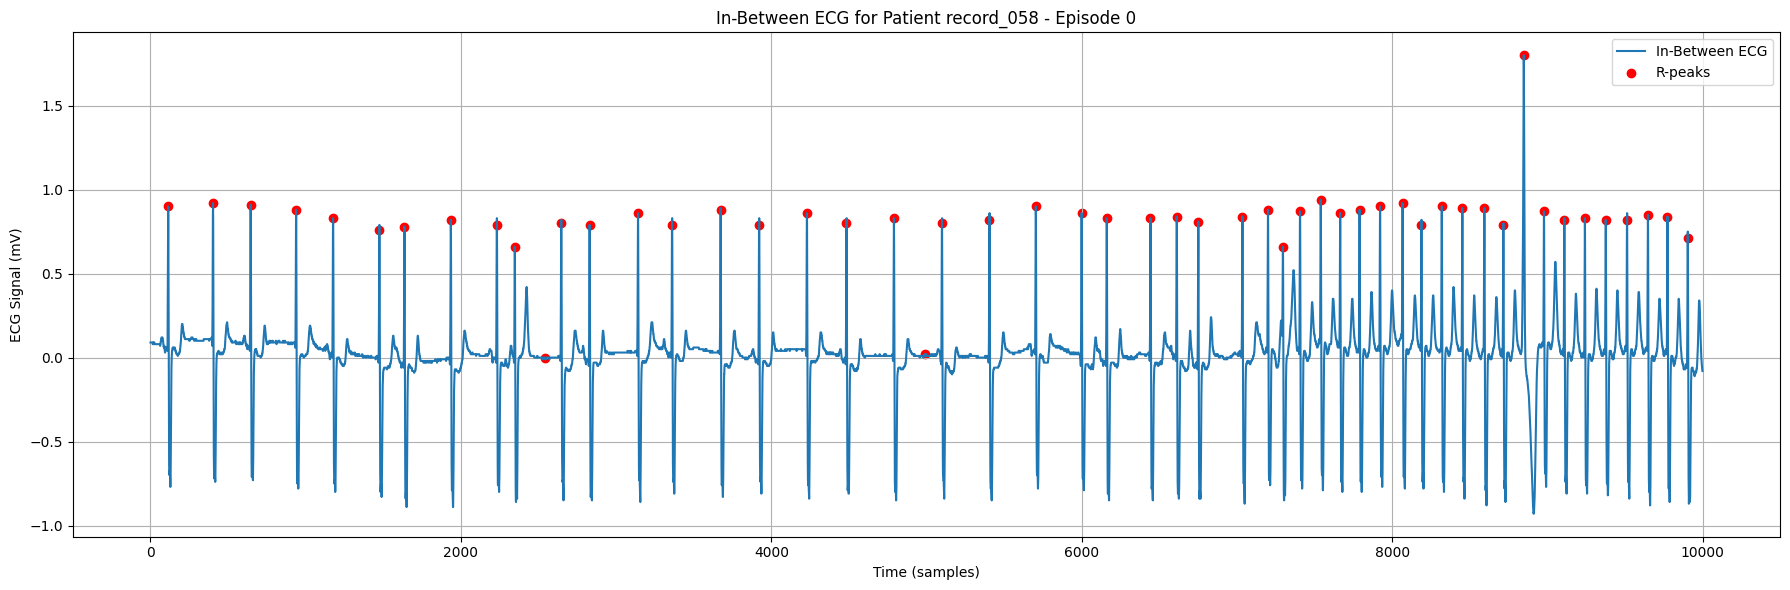

In [180]:
mean_inbetween_ecg = np.mean(inbetween_ecg)
print(f"Mean value of In-Between ECG: {mean_inbetween_ecg:.4f} mV")
plt.figure(figsize=(18, 6))
plt.plot(inbetween_ecg - mean_inbetween_ecg, label='In-Between ECG')
plt.scatter(rpeak_indices, inbetween_ecg[rpeak_indices] - mean_inbetween_ecg, color='red', label='R-peaks')
plt.title(f'In-Between ECG for Patient {patient} - Episode {episode}')
plt.xlabel('Time (samples)')
plt.ylabel('ECG Signal (mV)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [194]:
from scipy.interpolate import CubicSpline

x_new = np.arange(0, len(inbetween_ecg) * 5, 1)  # 1000 Hz = 5x more samples
x_original = np.arange(0, len(inbetween_ecg) * 5, 5)  # Original 200 Hz sample points
# interpolated_ecg = cs(x_original)  # Keep original scale for CubicSpline

# Upsample using the CubicSpline
cs_upsampled = CubicSpline(x_original, inbetween_ecg)
interpolated_ecg = cs_upsampled(x_new)

In [196]:
def get_interpolated_ecg(ecg_signal, rpeak_indices, original_sampling_rate, target_sampling_rate):

    old_length = len(ecg_signal)
    new_length = int(old_length * target_sampling_rate / original_sampling_rate)

    x_original = np.arange(old_length)
    x_new = np.linspace(0, old_length - 1, new_length)

    cs = CubicSpline(x_original, ecg_signal)
    interpolated_ecg = cs(x_new)

    return interpolated_ecg

In [199]:
interpolated_ecg = get_interpolated_ecg(inbetween_ecg, rpeak_indices, original_sampling_rate=200, target_sampling_rate=1000)

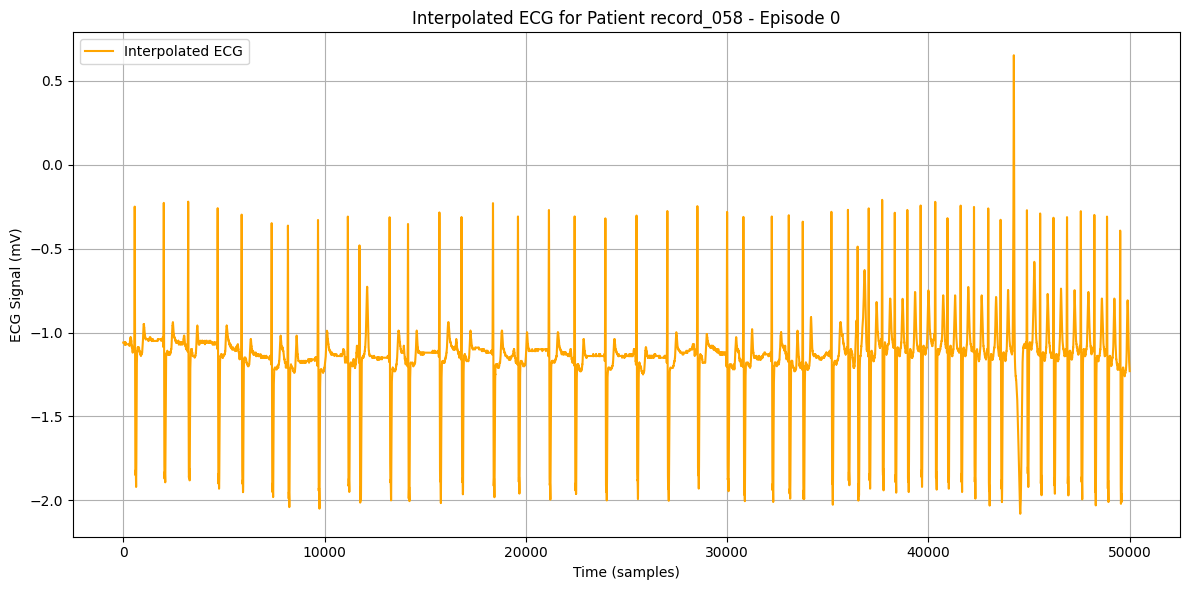

In [200]:
plt.figure(figsize=(12, 6))
plt.plot(interpolated_ecg, label='Interpolated ECG', color='orange')
plt.title(f'Interpolated ECG for Patient {patient} - Episode {episode}')
plt.xlabel('Time (samples)')
plt.ylabel('ECG Signal (mV)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [189]:
# Primary detection using UNSW (khamis2016)
r_peaks_primary = nk.ecg_findpeaks(interpolated_ecg, sampling_rate=1000, method='khamis2016')['ECG_R_Peaks']

# Secondary validation using NeuroKit
r_peaks_secondary = nk.ecg_findpeaks(interpolated_ecg, sampling_rate=1000, method='neurokit')['ECG_R_Peaks']

# Parameters (at 1000 Hz: 50ms = 50 samples, 100ms = 100 samples)
REFINE_WINDOW = 50   # ±50ms in samples
VALIDATE_WINDOW = 100  # ±100ms in samples

validated_peaks = []
inaccurate_peaks = []

for peak in r_peaks_primary:
    # Refinement Phase: find absolute local maximum within ±50ms window
    win_start = max(0, peak - REFINE_WINDOW)
    win_end = min(len(interpolated_ecg) - 1, peak + REFINE_WINDOW)
    refined_peak = win_start + np.argmax(interpolated_ecg[win_start:win_end + 1])

    # Validation Phase: check if secondary detector has a peak within ±100ms
    is_validated = np.any(np.abs(r_peaks_secondary - refined_peak) <= VALIDATE_WINDOW)

    if is_validated:
        validated_peaks.append(refined_peak)
    else:
        inaccurate_peaks.append(refined_peak)

r_peaks = {'ECG_R_Peaks': np.array(validated_peaks)}

print(f"Primary detections:    {len(r_peaks_primary)}")
print(f"Validated peaks:       {len(validated_peaks)}")
print(f"Flagged/excluded peaks:{len(inaccurate_peaks)}")

Primary detections:    49
Validated peaks:       49
Flagged/excluded peaks:0


In [190]:
_,rpeaks_corrected = nk.signal_fixpeaks(r_peaks['ECG_R_Peaks'], sampling_rate=1000, method='Kubios')
print(rpeaks_corrected)

[  570  2014  3227  4692  5882  7373  8181  9675 11158 11736 13233 14146
 15706 16804 18368 19608 21147 22423 23950 25498 27028 28521 29996 30806
 32217 33061 33755 35177 36001 37032 37700 38326 38950 39611 40336 40943
 41599 42261 42970 43583 44241 44891 45548 46209 46882 47568 48240 48870
 49524]


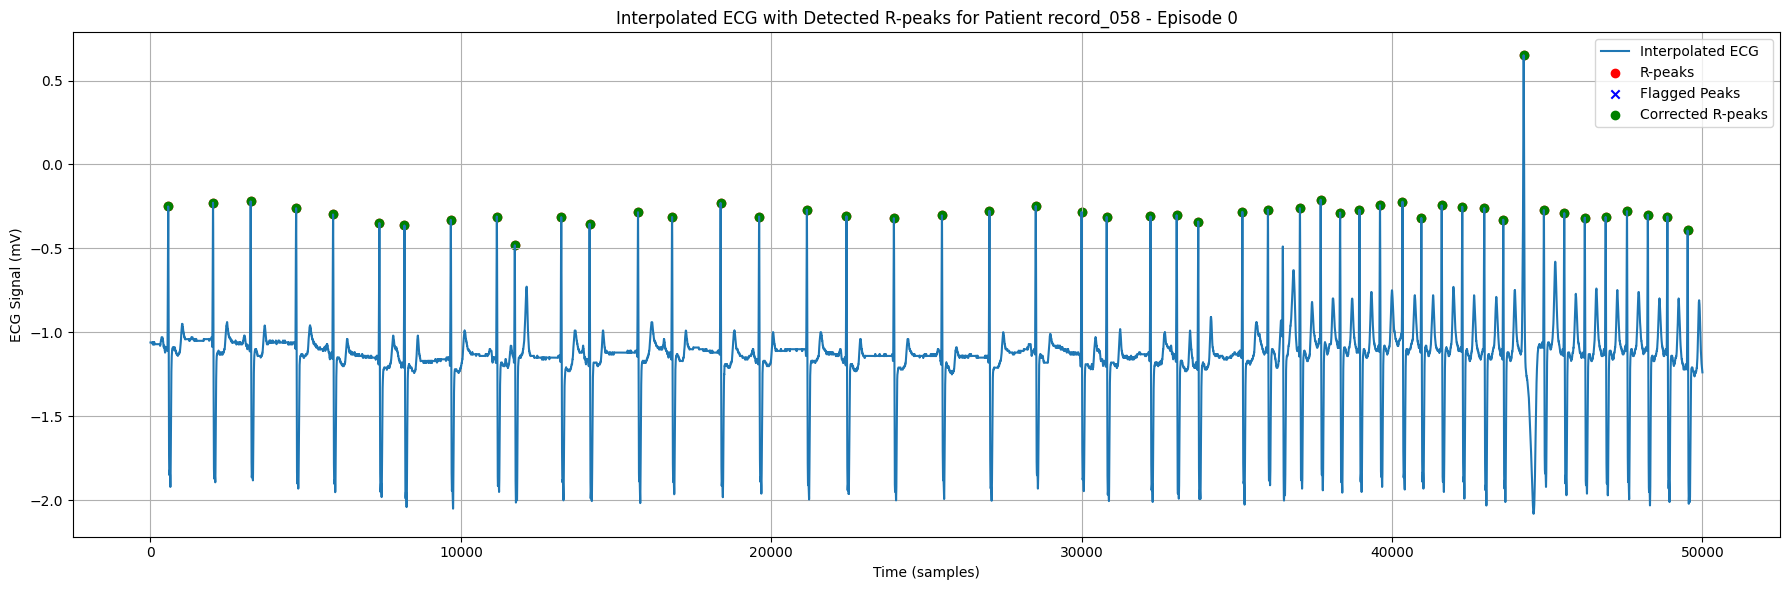

In [191]:
plt.figure(figsize=(18, 6))
plt.plot(interpolated_ecg, label='Interpolated ECG')
plt.scatter(r_peaks['ECG_R_Peaks'], interpolated_ecg[r_peaks['ECG_R_Peaks']], color='red', label='R-peaks')
plt.scatter(inaccurate_peaks, interpolated_ecg[inaccurate_peaks], color='blue', label='Flagged Peaks', marker='x')
plt.scatter(rpeaks_corrected, interpolated_ecg[rpeaks_corrected], color='green', label='Corrected R-peaks', marker='o')
plt.title(f'Interpolated ECG with Detected R-peaks for Patient {patient} - Episode {episode}')
plt.xlabel('Time (samples)')
plt.ylabel('ECG Signal (mV)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [83]:
signals,info = nk.ecg_process(pre_afib_ecg, sampling_rate=200)

In [84]:
r_peaks = info['ECG_R_Peaks']
print(f"R-peaks detected at indices: {len(r_peaks)}")
rr_intervals = np.diff(r_peaks)*5  # Convert to milliseconds
print(f"First 10 RR intervals (seconds): {rr_intervals[:10]}")

R-peaks detected at indices: 3901
First 10 RR intervals (seconds): [880 900 900 875 880 900 905 885 880 900]


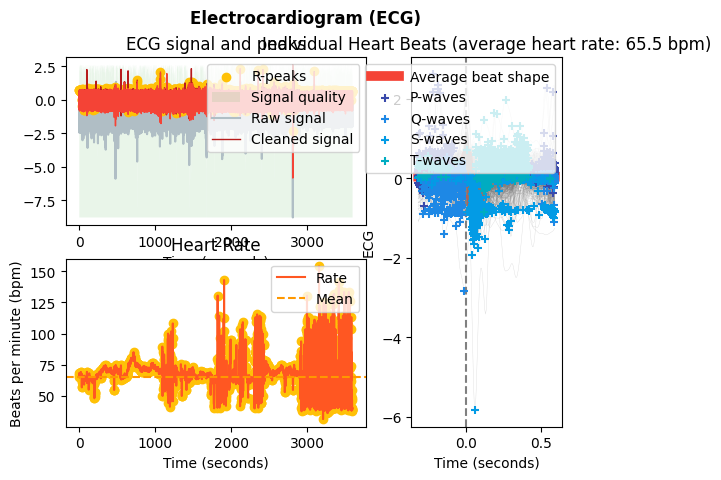

In [85]:
nk.ecg_plot(signals, info)

In [127]:
afib_rr = None
pre_afib_rr = None
with h5py.File(os.path.join(RECORD_DIR, f"{patient}_rr_00.h5"), 'r') as h5_file:
    # print(list(h5_file.keys()))  # List all datasets in the HDF5 file
    afib_rr = h5_file['rr'][11309:12309]  # Adjusted to match the length of pre_afib_rr
    pre_afib_rr = h5_file['rr'][10309:11309]
    combined = h5_file['rr'][10309:12309]
    print(len(h5_file['rr'][:]))

print(len(afib_rr))

99994
1000


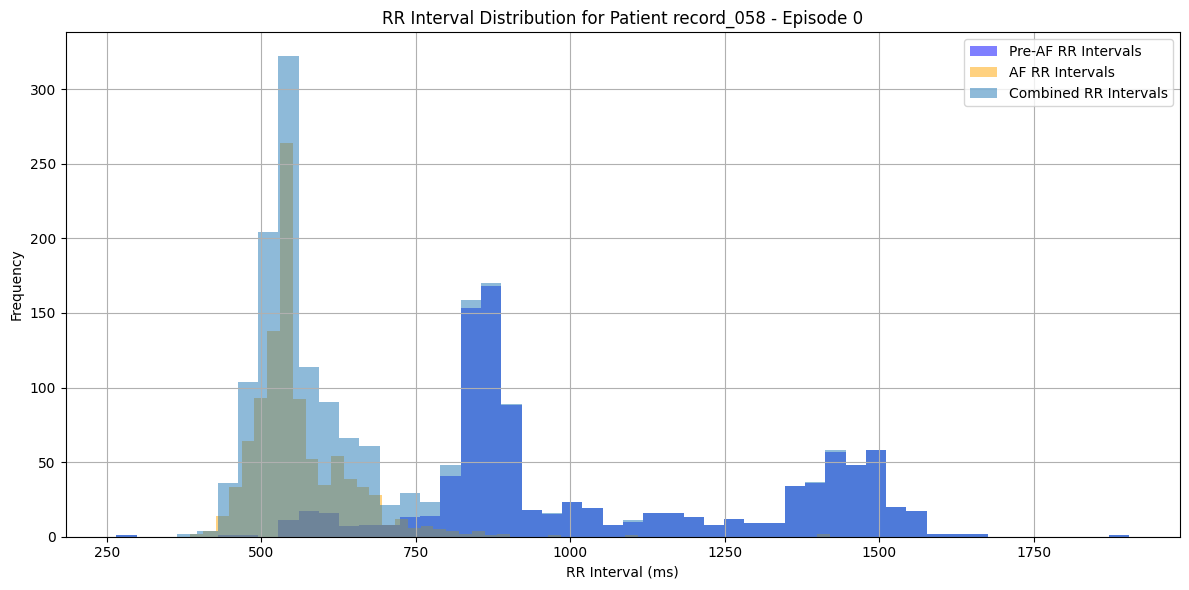

In [153]:
plt.figure(figsize=(12, 6))
plt.hist(pre_afib_rr, bins=50, alpha=0.5, label='Pre-AF RR Intervals', color='blue')
plt.hist(afib_rr, bins=50, alpha=0.5, label='AF RR Intervals', color='orange')
plt.hist(combined, bins=50, alpha=0.5, label='Combined RR Intervals')
plt.title(f'RR Interval Distribution for Patient {patient} - Episode {episode}')
plt.xlabel('RR Interval (ms)')
plt.ylabel('Frequency') 
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [150]:
from sklearn.preprocessing import StandardScaler,RobustScaler

scaler = StandardScaler()
scaler.fit(combined.reshape(-1,1))  # fit on all data or training set

pre_afib_scaled = scaler.transform(pre_afib_rr.reshape(-1,1))
afib_scaled = scaler.transform(afib_rr.reshape(-1,1))

In [151]:
print("Pre-AF: mean, std before scaling:", pre_afib_rr.mean(), pre_afib_rr.std())
print("AF: mean, std before scaling:", afib_rr.mean(), afib_rr.std())

print("Pre-AF: mean, std after scaling:", pre_afib_scaled.mean(), pre_afib_scaled.std())
print("AF: mean, std after scaling:", afib_scaled.mean(), afib_scaled.std())

Pre-AF: mean, std before scaling: 1049.225 288.91940809679085
AF: mean, std before scaling: 561.545 86.30867844544952
Pre-AF: mean, std after scaling: 0.7527943006821779 0.8919655666491653
AF: mean, std after scaling: -0.7527943006821778 0.26645620584459123


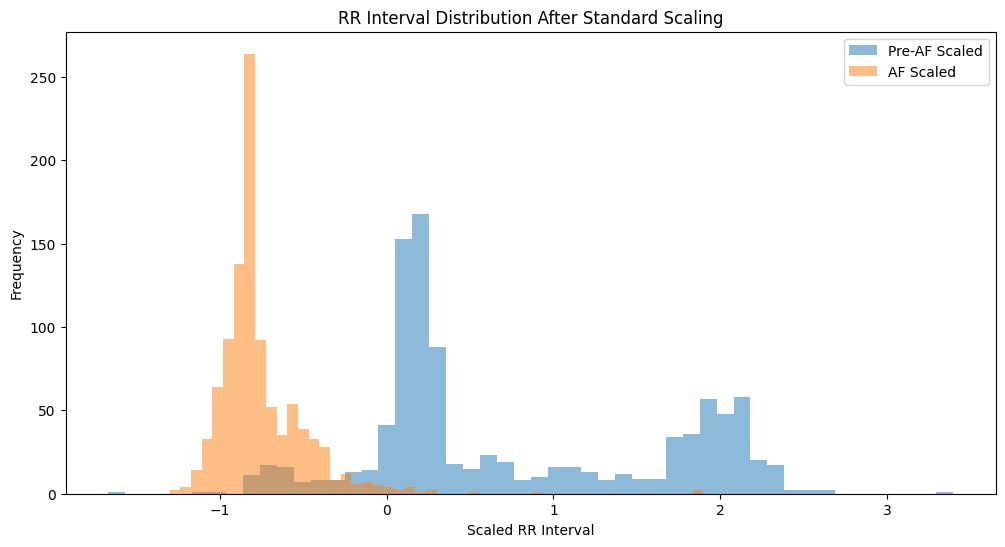

In [152]:
plt.figure(figsize=(12,6))
plt.hist(pre_afib_scaled, bins=50, alpha=0.5, label='Pre-AF Scaled')
plt.hist(afib_scaled, bins=50, alpha=0.5, label='AF Scaled')
plt.title('RR Interval Distribution After Standard Scaling')
plt.xlabel('Scaled RR Interval')
plt.ylabel('Frequency')
plt.legend()
plt.show()

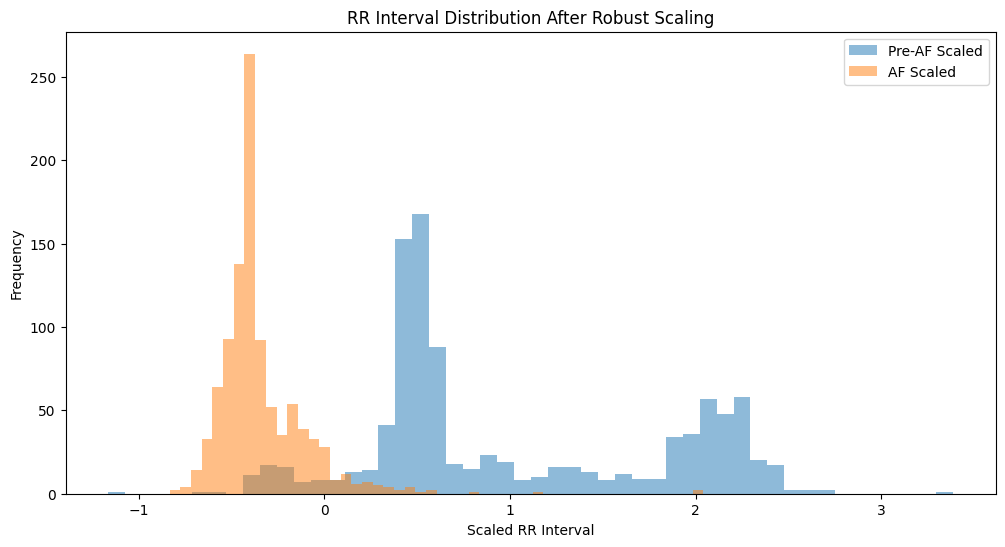

In [149]:
plt.figure(figsize=(12,6))
plt.hist(pre_afib_scaled, bins=50, alpha=0.5, label='Pre-AF Scaled')
plt.hist(afib_scaled, bins=50, alpha=0.5, label='AF Scaled')
plt.title('RR Interval Distribution After Robust Scaling')
plt.xlabel('Scaled RR Interval')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [123]:
print(f"RR intervals more than 3000 ms: {np.sum(pre_afib_rr > 3000)}")
print(f"RR intervals less than 300 ms: {np.sum(afib_rr < 300)}")

RR intervals more than 3000 ms: 0
RR intervals less than 300 ms: 17


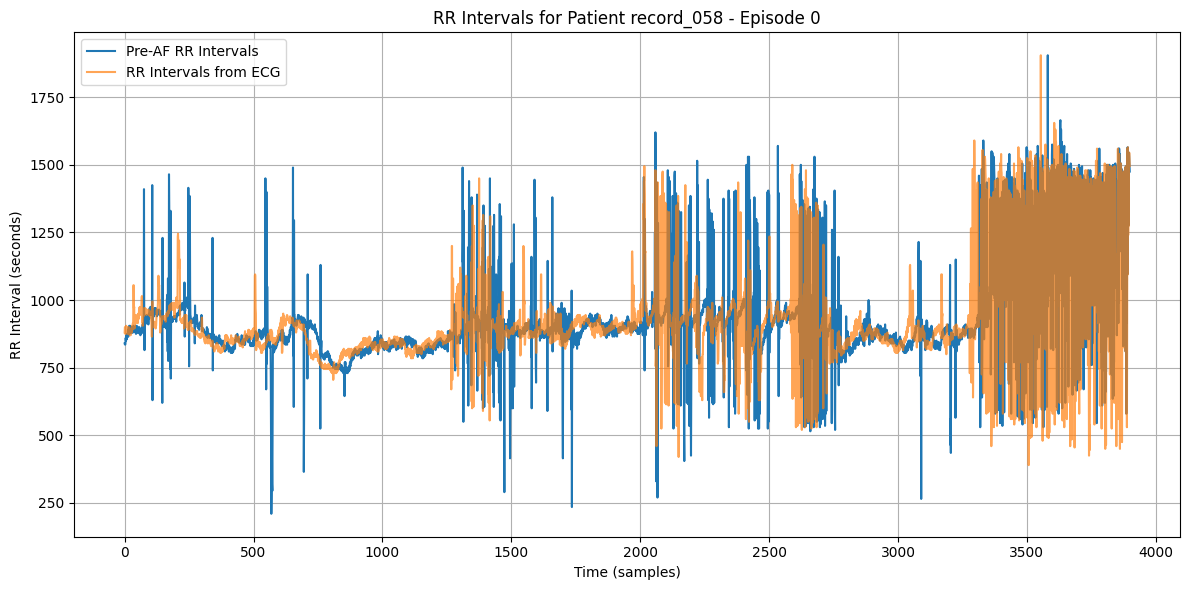

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(pre_afib_rr, label='Pre-AF RR Intervals')
plt.plot(rr_intervals, label='RR Intervals from ECG', alpha=0.7)
plt.title(f'RR Intervals for Patient {patient} - Episode {episode}')
plt.xlabel('Time (samples)')
plt.ylabel('RR Interval (seconds)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

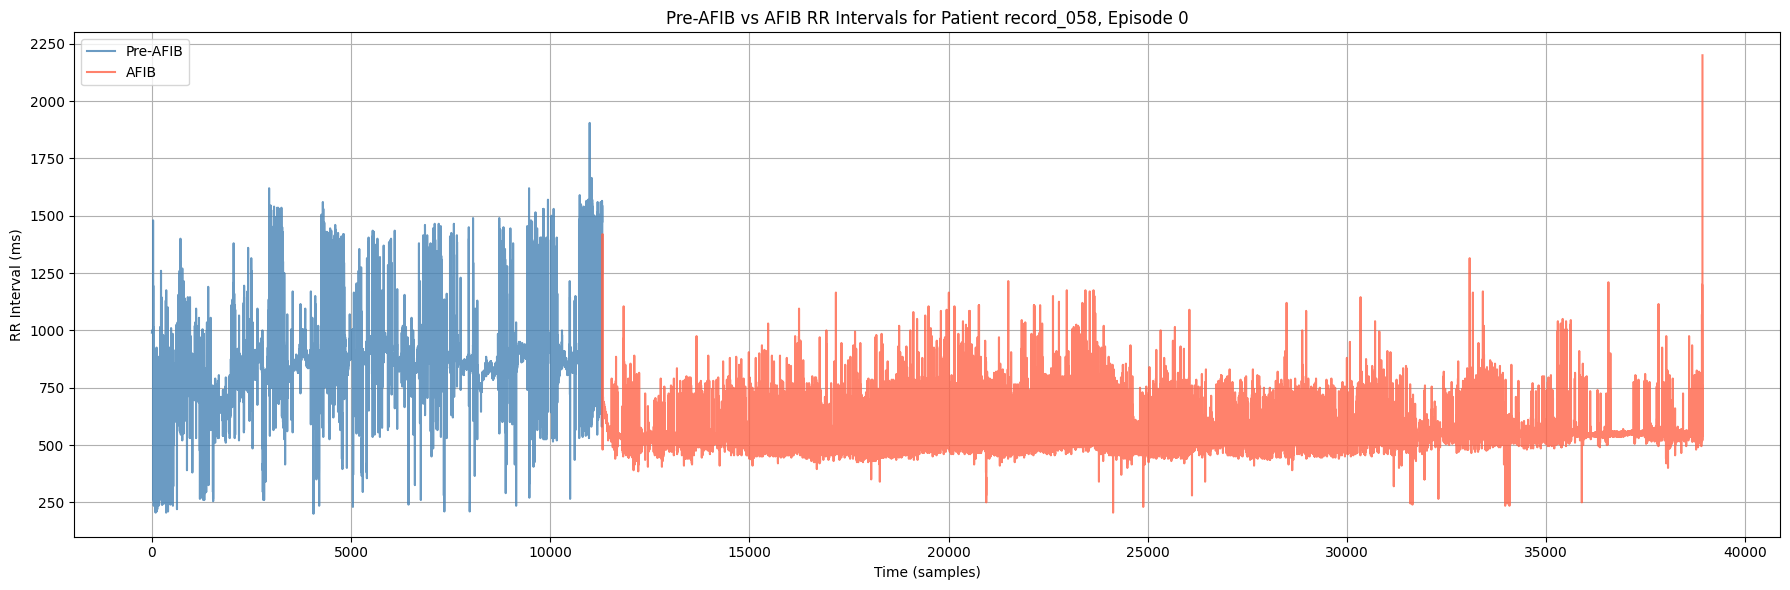

In [50]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(pre_afib_rr, label='Pre-AFIB', color='steelblue', alpha=0.8)
ax.plot(range(len(pre_afib_rr), len(pre_afib_rr) + len(afib_rr)), afib_rr, label='AFIB', color='tomato', alpha=0.8)
ax.set_title(f'Pre-AFIB vs AFIB RR Intervals for Patient {patient}, Episode {episode}')
ax.set_xlabel('Time (samples)')
ax.set_ylabel('RR Interval (ms)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.savefig(os.path.join(EXPORT_DIR, f'{patient}_{episode}_pre_afib_vs_afib_rr_intervals.png'))
plt.show()

In [51]:
print(f'Minimum RR Interval in Pre-AFIB: {np.min(pre_afib_rr)} ms')
print(f'Maximum RR Interval in Pre-AFIB: {np.max(pre_afib_rr)} ms')
print(f'Mean RR Interval in Pre-AFIB: {np.mean(pre_afib_rr)} ms')
print(f'Minimum RR Interval in AFIB: {np.min(afib_rr)} ms')
print(f'Maximum RR Interval in AFIB: {np.max(afib_rr)} ms')
print(f'Mean RR Interval in AFIB: {np.mean(afib_rr)} ms')

Minimum RR Interval in Pre-AFIB: 200 ms
Maximum RR Interval in Pre-AFIB: 1905 ms
Mean RR Interval in Pre-AFIB: 887.0342205323194 ms
Minimum RR Interval in AFIB: 205 ms
Maximum RR Interval in AFIB: 2200 ms
Mean RR Interval in AFIB: 562.9641564083997 ms


In [58]:
minimum_rr_index = np.argmin(pre_afib_rr)
print(f'Minimum RR Interval occurs at index: {minimum_rr_index}')

Minimum RR Interval occurs at index: 4056


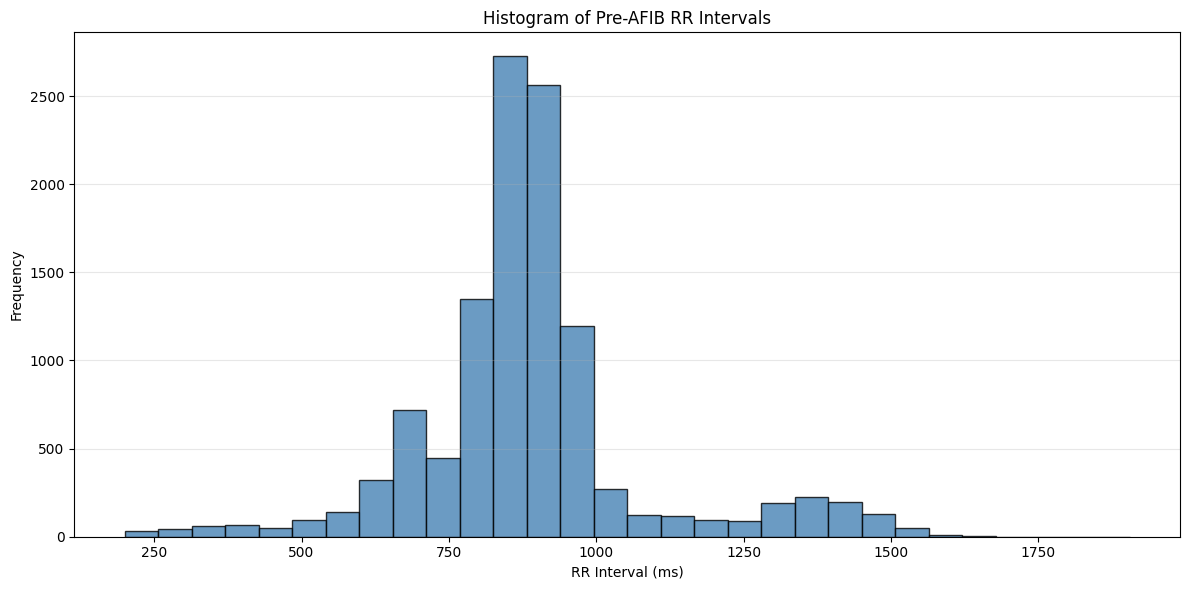

In [52]:
plt.figure(figsize=(12, 6))
plt.hist(pre_afib_rr, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Histogram of Pre-AFIB RR Intervals')
plt.xlabel('RR Interval (ms)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
data = []
for file_name in file_names:
    rr_intervals = np.load(os.path.join(DATA_DIR, f"{file_name}.npy"))
    data.append(rr_intervals)

data = np.array(data)

['record_004_rr_labels.csv', 'record_004_ecg_labels.csv', 'record_004_ecg_00.h5', 'record_004_rr_00.h5']


In [166]:

rpeaks = np.load(os.path.join(EXPORT_DIR, "record_034_peaks_segmented.npy"))

In [167]:
window_size = 200
stride = 20
windows = []
MeanNN = []
SDNN = []
RMSSD = []
SDSD = []
CVNN = []
CVSD = []
pNN50 = []
for i in range(0, len(rpeaks) - window_size + 1, stride):
    windows.append(rpeaks[i:i + window_size])
    hrv_time = nk.hrv_time(rpeaks[i:i + window_size], sampling_rate=1000, show=False)
    # print(hrv_time)
    # break
    MeanNN.append(hrv_time['HRV_MeanNN'].values[0])
    SDNN.append(hrv_time['HRV_SDNN'].values[0])
    RMSSD.append(hrv_time['HRV_RMSSD'].values[0])   
    SDSD.append(hrv_time['HRV_SDSD'].values[0])
    CVNN.append(hrv_time['HRV_CVNN'].values[0])
    CVSD.append(hrv_time['HRV_CVSD'].values[0])
    pNN50.append(hrv_time['HRV_pNN50'].values[0])



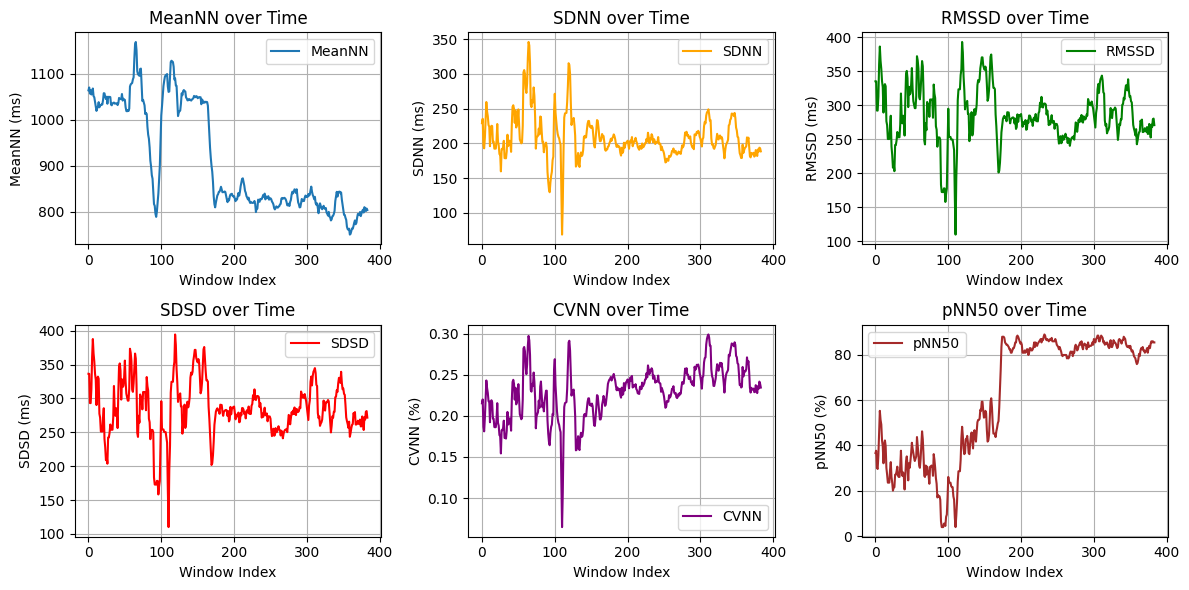

In [168]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.plot(MeanNN, label='MeanNN')
plt.title('MeanNN over Time')
plt.xlabel('Window Index')
plt.ylabel('MeanNN (ms)')
plt.legend()
plt.grid()
plt.subplot(2, 3, 2)
plt.plot(SDNN, label='SDNN', color='orange')
plt.title('SDNN over Time')
plt.xlabel('Window Index')
plt.ylabel('SDNN (ms)')
plt.legend()
plt.grid()
plt.subplot(2, 3, 3)
plt.plot(RMSSD, label='RMSSD', color='green')
plt.title('RMSSD over Time')
plt.xlabel('Window Index')
plt.ylabel('RMSSD (ms)')
plt.legend()
plt.grid()
plt.subplot(2, 3, 4)
plt.plot(SDSD, label='SDSD', color='red')
plt.title('SDSD over Time')
plt.xlabel('Window Index')
plt.ylabel('SDSD (ms)')
plt.legend()
plt.grid()
plt.subplot(2, 3, 5)
plt.plot(CVNN, label='CVNN', color='purple')
plt.title('CVNN over Time')
plt.xlabel('Window Index')
plt.ylabel('CVNN (%)')
plt.legend()
plt.grid()
plt.subplot(2, 3, 6)
plt.plot(pNN50, label='pNN50', color='brown')
plt.title('pNN50 over Time')
plt.xlabel('Window Index')
plt.ylabel('pNN50 (%)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()